# PyTorch & Neural Networks
These exercises will be an introduction to Torch and neural networks. So far you should have at least a general idea of what neural networks are. What I now imagine the main question on your mind is how do I begin programming them? While there are many different Python libraries that can be used for the purpose, most of our work is done using PyTorch. PyTorch is a library which is used for machine learning and creating neural networks. This notebook is an exploration of not only how to build a basic neural network but what parts make up PyTorch. This can be spit into 3 main parts:
- What is a Tensor, and how is it different from a Numpy array and a Pandas dataframe.
- What is a dataloader, and how do we make one.
- What is a neural network, and how do modules allow us to implement them.

The reason we use PyTorch rather than its rival Tensorflow is that currently the academic community seem to prefer it. This means no matter what topic we are studying their is a large chance its code is written in Torch.

In [4]:
import numpy as np
import torch
import torch.nn as nn
from torch.nn import Module
import torch.optim as optim
from torch.optim import Optimizer
from torch.utils.data import Dataset, DataLoader, random_split
from torch import Tensor
from torchvision import datasets
from torchvision.transforms import ToTensor
import torchvision.transforms as transforms
from typing import Tuple, List, Dict
import matplotlib.pyplot as plt
import time
import pandas as pd
type LossFN = Union[Module]

In [7]:
# This a is common toy example within neural networks
# In this dictionary the key (bool, bool) is the data,
# and the item bool is the label. (False, False) has label False, etc.
xor_data = {(False, False): False, (False, True): True, (True, False): True, (True, True): False}

class XORDataset(Dataset):
    def __init__(self, data):
        """Initiliase the XOR problem's dataset"""
        # Note normally you would start by reading a csv file
        # or getting the locations of pictures.
        # Do some modifications to turn it into a tensor
        inputs = [list(k) for k in data.keys()]
        labels = [v for v in data.values()]

        # Save these tensors so that we can use them later
        # variable names don't matter, just make them clear
        self.input = torch.tensor(inputs, dtype=torch.float32)
        self.label = torch.tensor(labels, dtype=torch.float32).view(-1, 1)

    def __len__(self) -> int:
        """Get length of our dataset"""
        # Simply return length of our data
        return len(self.input)

    def __getitem__(self, idx: int) -> Tuple[Tensor, Tensor]:
        """Get an item from idx"""
        x = self.input[idx] # get data from inputs
        y = self.label[idx] # get data from label
        return x, y # return them as a tuple so we can unpack

# Wrap the classes in a dataloader, this will allow us to easily retrieve the data
xor_dataset = XORDataset(xor_data)
xor_dataloader = DataLoader(xor_dataset, batch_size=1, shuffle=True)

# Print dataset
for batch_idx, (x, y) in enumerate(xor_dataloader):
    print(f"Batch {batch_idx + 1}\nInputs: {x}\nLabels: {y}")

Batch 1
Inputs: tensor([[0., 0.]])
Labels: tensor([[0.]])
Batch 2
Inputs: tensor([[1., 1.]])
Labels: tensor([[0.]])
Batch 3
Inputs: tensor([[0., 1.]])
Labels: tensor([[1.]])
Batch 4
Inputs: tensor([[1., 0.]])
Labels: tensor([[1.]])


### **(Question 1)** Create a dataset for insurance
Last lesson we created a basic machine learning model from the insurance dataset. This dataset attempts to predict the cost of health-care given a few details. We want to wrap the dataset in PyTorch's dataset. An important part is to make sure that it returns items as tensors. Below is a reminder of some code we used last workshop which may help. This uses numpy so be sure to translate this code into tensors?
```python
data = pd.read_csv('data/insurance.csv')
x = data["age"].to_numpy()
y = data["charges"].to_numpy()
```

**Create a basic dataset for the WHOLE insurance that takes as input a path during initialisation and outputs a tensor representing the age of an individual. This should then be turned into a DataLoader for the dataset**. Remember that the `sex` and `smoker` columns need to be encoded.

In [8]:
class InsuranceDataset(Dataset):
    def __init__(self, path: str):
        """Read the dataset and get the input as a tensor, ensuring all columns are encoded"""
        #!Answer
        # Remove region
        df = pd.read_csv(path)
        df = df.drop(columns=["region"])

        # Encode the data
        df["sex"] = df["sex"].map({"female": 1, "male": 0})
        df["smoker"] = df["smoker"].map({"yes": 1, "no": 0})
        
        # Seperate x, y
        x = df.drop(columns=["charges"]).values
        y = df["charges"].values
        
        # Convert them to PyTorch tensors
        self.x = torch.tensor(x, dtype=torch.float32)
        self.y = torch.tensor(y, dtype=torch.float32)

    def __len__(self) -> int:
        """Get the amount of insurance entries"""
        #!Answer
        return len(self.x)

    def __getitem__(self, idx: int) -> Tuple[Tensor, Tensor]:
        """Get an item representing the """
        #!Answer
        return self.x[idx], self.y[idx]

After you have created you dataset wrap it in the `dataloader` class with a batch size of 1.

In [10]:
path = "data/insurance.csv"
insurance_data = InsuranceDataset('../data/insurance.csv') # Fill in this to create the dataset
dataloader = 

SyntaxError: invalid syntax (407312990.py, line 3)

### **(Question 2)** Splitting the data
Before training can be done on a dataset needs to be split into two (sometimes three parts). These parts are the **training dataset** which is used by our neural network to train the network, and our **testing dataset** which tests how well our models function against random data. This is usually done with a 80/20 or 70/30 split, although this is fairly dependent on the dataset.

To

**Split the dataset into a 80/20 split**. To achieve this keep in mind the function `random_split(dataset, (...))`

In [2]:

# Split the data
insurance_data = InsuranceDataset(path)

# Compute train_size, test_size and use random split
#!Answer
train_size = int(0.8 * len(insurance_data))
test_size = len(insurance_data) - train_size
insurance_data, insurance_data_test = random_split(insurance_data, (train_size, test_size))

NameError: name 'InsuranceDataset' is not defined

In [ ]:

# Create data loaders
insurance_loader = DataLoader(insurance_data)
insurance_loader_test = DataLoader(insurance_data_test)

In [7]:
for batch_idx, (x, y) in enumerate(insurance_loader):
    print(f"Inputs: {x}\nResult: {y}") # Print first results
    break # Don't worry if not exactly the same

Inputs: tensor([[28.0000,  0.0000, 23.8000,  2.0000,  0.0000]])
Result: tensor([3847.6741])


### **(Question 2)** Expand the dataloader
Before we move on lets expand our model further. Currently we are only considering age but with tensors we can consider a list of inputs rather than one. This means that we can easily expand our input to have more features, which will improve our model when we decide to train it.

**Expand your dataloader to include bmi and amount of children**. When you run the above code it should output a tensor with three values as the input.

In [8]:
# Just to remind you of the data we are looking at
pd.read_csv('data/insurance.csv').head()

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


In [9]:
d = len(next(iter(insurance_loader))[0][0])
if d % 3 != 0 and d % 5 != 0:
    print("Unsucessfully added bmi and children")

### **(Question 3)** Encoding data in the dataloader
Now that we are considering more inputs our model should improve. Despite this we are missing whether they are a smoker and their gender. If we were to just put them into the tensor we would run into an issue though, the data needs to be a float, which both fields aren't as they are strings (called object by Pandas). To fix this we need to encode the data into a format we can use. This can be done through two main approaches:
- Label encoding, where every category is encoded as an integer. This can be done automatically or done by using a relevant number, such as the amount of appearences. For example a smoker could be classified as `1` while a non-smoker could be classified as `0`
- On hot encoding, where each category is represented as $n$ Boolean columns, where $n$ is the amount of categories. Below is an example with `RainToday`.

| ID | Smoker |
| ---- | ----- |
| 0 | Yes |
| 1 | No |

| ID | Yes | No |
| --- | ---- | ----- |
| 0 | 1 | 0 |
| 1 | 0 | 1 |

**Expand your dataset to have smoker and sex as a part of the tensor by encoding them as floats**.
<details>
  <summary>Hint</summary>
    Some functions which may be useful depending on the approach used are:
    <ul>
        <li><code>pd.get_dummies</code></li>
        <li><code>dataset[...].map({})</code></li>
        <li><code>OneHotEncoder</code> from sklearn</li>
        <li><code>LabelEncoder</code> from sklearn</li>
    </ul>
</details>

In [10]:
d = len(next(iter(insurance_loader))[0][0])
if d % 5 and d % 6 :
    print("Unsucessfully added smoker and sex")

### **(Question 4)** Split the Dataset
Currently the dataset only consists of one main dataset which iterates through all entries. This causes problems however as after we train the model and give it new data it may be predicting what our data says rather than predicting it from the trends. To avoid this we usually split the dataset into 2 halves, the training set and the testing set.
- Training set, consists of most of the data usually 75% and above, and is used to train our ML model.
- Testing set, consists of the rest of the data, and is used to test our dataset at increments to make sure it still accurately predicts cases where it encounters new data.

By splitting the dataset we are able to reduce overfitting and see how our accurate our model is. So before we go about training we first need to go about splitting it. This is done by first calculating the training sizes and test sizes. Before then using `random_split` to split the data. After we have done this we can create new dataloaders for both training and testing data.

**Split the dataset as to create a new training and testing dataloader, where training consists of 80% of the data**. Do it once again in the above code.

## Convolutional Neural Networks
Now that we have a basic idea of how a neural network works we can expand these concepts to CNNs by letting you do a basic example. 

### Hand-Writing Recognition
Hand-writing recognition is a classic problem neural network that involves recognising numbers from people's hand-writing. For example if we see a drawn 6 we want our model to output a 6. In fact this problem is so common we can save some time by downloading the dataset from Torch. Looking at the call below we see this is fairly similar to calling our own dataset.

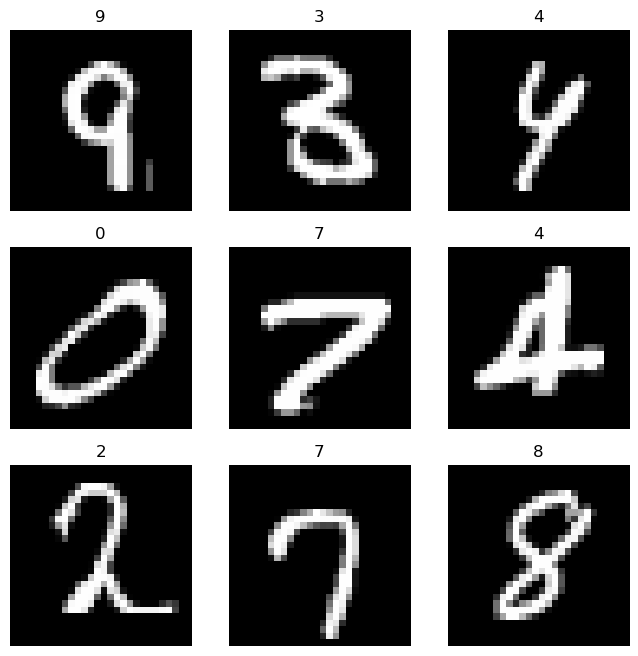

In [14]:
# Remember this place for later
preprocessing = transforms.ToTensor()

# Download training data from torch
training_data = datasets.QMNIST(
    root="data",
    train=True,
    download=True,
    transform=preprocessing,
)

# Download test data from torch
test_data = datasets.QMNIST(
    root="data",
    train=False,
    download=True,
    transform=ToTensor(),
)

# Create dataloaders
batch_size = 64
train_dataloader = DataLoader(training_data, batch_size=batch_size)
test_dataloader = DataLoader(test_data, batch_size=batch_size)

# Display the data
figure = plt.figure(figsize=(8, 8))
cols, rows = 3, 3
for i in range(1, cols * rows + 1):
    sample_idx = torch.randint(len(training_data), size=(1,)).item()
    img, label = training_data[sample_idx]
    figure.add_subplot(rows, cols, i)
    plt.title(label)
    plt.axis("off")
    plt.imshow(img.squeeze(), cmap="gray")
plt.show()

### **(Question 5)** Model
Now that we have seen our data our first goal is to make a basic neural network for our dataset. This involves creating a module like before. An important part to keep in mind is that we can't accept this data in its 2d form. As such our first step is to `flatten` the data. Once this is done we can move onto building out our layers and activation functions.

**Build a basic neural network**. Focus on it working at first, we can improve this later.

In [15]:
class QMNISTNet(Module):
    def __init__(self):
        """Layers for our handwritting model"""
        super().__init__()
        self.flatten = nn.Flatten() # This is needed for imaging data
        self.linear_relu_stack = nn.Sequential(
            nn.Linear(28*28, 512),
            nn.ReLU(),
            nn.Linear(512, 512),
            nn.ReLU(),
            nn.Linear(512, 10)
        )

    def forward(self, x: Tensor):
        """Give handwritting prediction"""
        x = self.flatten(x)
        logits = self.linear_relu_stack(x)
        return logits

### **(Question 6)** Training
From our previous example we saw how you would go about training and testing a model. Our first order of business is to make it less messy. A nice way of doing this is by declaring seperate function for `train` and `test`. This will allow us to take parameters such as the dataloader, model, loss function, and optimiser as arguments which can be useful if we want to test multiple different things. Similar to last time you need to iterate through your data, forward pass, and back pass. Look at the previous example if you need some help.

**Create a function that takes in a dataloder, a model, a loss function, an optimiser, and trains the network**. This function will be called every epoch so don't worry about making a loop for the amount of epochs here. 

In [16]:
def train(dataloader: DataLoader, model: Module, loss_fn: LossFN, optimiser: Optimizer):
    """Train the model using the training set"""
    model.train()
    for batch, (X, y) in enumerate(dataloader):
        X, y = X.to(device), y.to(device)
        
        # Compute prediction error
        pred = model(X)
        loss = loss_fn(pred, y)

        # Backpropagation
        loss.backward()
        optimiser.step()
        optimiser.zero_grad()

### **(Question 7)** Testing
Once we have finished running training we can now test the model against our testing dataset. This will provide us with a look into its current loss and accuracy. This will be more different to our previous example as we now want to calculate both the loss and accuracy after running the test function. This will be done similar to training however rather than backpropagating we store our loss and accuracy, allowing us to print them at the end of the epoch.

**Create a test function that computes the loss and accuracy for data in the test dataloader**. Make sure to divide the loss and accuracy at the end. To predict our accuracy you can calculate from a prediction `pred`, and a label `y` the result to be:
```python
res = pred.argmax(dim=1, keepdim=True)
acc += res.eq(y.view_as(res)).sum().item()
```

In [17]:
def test(dataloader: DataLoader, model: Module, loss_fn: LossFN):
    """Test the model to see how it compares against the test portion of the dataset"""
    n = len(dataloader.dataset)
    n_batch = len(dataloader)
    loss = 0
    acc = 0
    model.eval() # Set Torch to evaluation mode
    with torch.no_grad(): # This step removes gradient descent modifications
        for X, y in dataloader:
            X, y = X.to(device), y.to(device)
            pred = model(X)
            loss += loss_fn(pred, y).item()
            res = pred.argmax(dim=1, keepdim=True)
            acc += res.eq(y.view_as(res)).sum().item()
    loss /= n_batch
    acc /= n
    print(f"Accuracy: {(acc):>0.1f}%, Avg loss: {loss:>8f}")

### **(Question 8)** Loss & Optimiser
The final step before we can run our model is choosing a loss function and optimiser. For now you can just enter the previously used ones, however be sure to change these later to see how the accuracy changes given these variables.

**Choose a loss function and optimiser**.

In [18]:
model = QMNISTNet()
loss_fn = nn.CrossEntropyLoss()
optimiser = torch.optim.SGD(model.parameters(), lr=1e-3)

### Results
Given that you have done the previous steps correctly you should be able to run the below code as to train the model for yourself. This code runs 10 epochs before finishing. If you are willing to spend more time training be sure to modify the amount of epochs. Don't expect this to be super accurate on the first try as we are still learning.

In [19]:
epochs = 10
for t in range(epochs):
    print(f"Epoch {t+1}/{epochs}: ", end="")
    train(train_dataloader, model, loss_fn, optimiser)
    test(test_dataloader, model, loss_fn)
print("Done!")

Epoch 1/10: Accuracy: 0.4%, Avg loss: 2.260161
Epoch 2/10: Accuracy: 0.5%, Avg loss: 2.204112
Epoch 3/10: Accuracy: 0.6%, Avg loss: 2.111032
Epoch 4/10: Accuracy: 0.6%, Avg loss: 1.950027
Epoch 5/10: Accuracy: 0.7%, Avg loss: 1.697428
Epoch 6/10: Accuracy: 0.7%, Avg loss: 1.384210
Epoch 7/10: Accuracy: 0.8%, Avg loss: 1.106342
Epoch 8/10: Accuracy: 0.8%, Avg loss: 0.912434
Epoch 9/10: Accuracy: 0.8%, Avg loss: 0.783257
Epoch 10/10: Accuracy: 0.8%, Avg loss: 0.693901
Done!


### **(Question 9)** Preprocessing
Now that you have done all the previous steps you should have a model that ranges from ok to pretty decent. However, one thing that may be holding you back is the lack of preprocessing. So what is preprocessing and how can we use it?

Preprocessing is the idea of modifying your data before you use it in a network. An example you have already done is back when you encoded male and female as 0 and 1. Another example can also be filling in data points that you can't find with a mean/median. With images this approach is different, rather we want to normalise the data, do rotations, change pixels and more.

The goal with preprocessing in general is to make our dataset more generalisable so that it not only can have an easier time training, but be able to be ran on new data and get a more accurate result. Below is an example of how we can change the preprocessing steps in our code. This creates a pipeline that starts by rotating before turning our input to a tensor.
```python
preprocessing = transforms.Compose([
    transforms.RandomRotation((0, 360)),
    transforms.ToTensor(),
])
```

**Modify the preprocessing step to be more advanced**. This step can be found in the place you downloaded the dataset. Be sure to experiment with different things not just rotations.

### **(Question 10)** Improve your Model
Congratulations you have trained a neural network. Most likely the results from this will be less than satisfactory, with it being possibly lower than 50%. Now this is only the start of your journey, every single variable whether your *loss function*, *optimiser (and its learning rate)*, *extracted features*, *model layers*, and more can be changed as to create a better model. This process if called **hyperparameter tuning** and is a large part of machine learning. If you ever want to get better at ML you must be willing to spend the time the improve your model. Therefore the last task is:

**Improve your model to have a better accuracy**. Tune respective parameters as to produce the best result possible. This will require some research.

In [20]:
# If you want to pretify your loss and accuracy graphs here:
def plot_loss_acc(loss: List[int], acc: List[int]):
    """Helper to plot loss and accuracy if you store them in a list"""
    fig, (ax0, ax1) = plt.subplots(1,2,figsize=(16,5))
    ax0.plot(acc, 's-')
    ax0.set_title(f'Final test accuracy {acc[-1]:.2f}%')
    ax0.set_ylabel('Accuracy%')
    ax0.set_xlabel('Epochs')
    ax1.plot(loss, 's-')
    ax1.set_title(f'Final test loss {loss[-1]:.2f}')
    ax1.set_ylabel('Loss')
    ax1.set_xlabel('Epochs')